# project proposal
### data source link: https://data.montgomerycountymd.gov/Health-and-Human-Services/Food-Inspection-LIVES-standard/ft84-r7wr

### data source discovered: blackboard>course materials>list of data sources>data.gov

the data set I have selected for project 2 is about food inspection-LIVES standard. This data set is updated weekly by the department of health and human services. this data is free to download. data is legal to access. Documented EDA is not available for the data. this data consists of 16.4k rows and 16 columns. size of data is 3.2MB. This data consists of different food business names, addresses, inspection IDs, inspection dates, inspection type, inspection results, and violence information. I selected this data because it consists of information on food inspection in all food-related businesses and it is a small data set. I also think that this data set will help me to apply methods learned in the class and also to learn the objectives of 601.

### hypothesis:

1. more food businesses are located in silver spring

 yes

2. more inspections occured in 2015

 no

3. most of the inspection results is fail

 no

4. routine food inspection is done mostly

 yes

5. many acts of violence that occurred during food inspection are critical.

 yes



In [1]:
#importing required libraries
import pandas as p                #pandas mainly for dataframes
import numpy as n                 #numpy for mathematicak operations and numerical extension of matplotlib
import matplotlib.pyplot as plot  # for data visualization and graphs

# data source

In [2]:
#reading the food lives inspection data
df=p.read_csv("C:/Users/pragathi/OneDrive/Desktop/Untitled Folder/601/Food_Inspection_-_LIVES_standard.csv")

In [3]:
df.shape  #printing no.of rows and columns in the data

(16404, 16)

In [4]:
df.head()   #printing top 5 rows of the data

,business_id,business_name,business_address,business_city,business_state,business_postal_code,business_latitude,business_longitude,business_location,inspection_id,inspection_date,inspection_result,inspection_type,violation_id,violation_description,violation_critical
0,1428,LAKEWOOD COUNTRY CLUB,13901 GLEN MILL RD.,ROCKVILLE,MD,20850,39.0830,-77.1944,"(39.083, -77.1944)",1428_2016-04-26,04/26/2016 12:00:00 AM,PASS,routine,NaN,NaN,NaN
1,19125,JIREH RESTAURANT,706 UNIVERSITY BLVD. E.,SILVER SPRING,MD,20903,38.9991,-76.9946,"(38.9991, -76.9946)",19125_2015-06-02,06/02/2015 12:00:00 AM,PASS,routine,19125_2015-06-02_ColdHoldingTemperature(C),Standard not met: Cold Holding Temperature (C),True
2,20167,7-ELEVEN #39156,8472 PINEY BRANCH RD,SILVER SPRING,MD,20901,38.9983,-77.0045,"(38.9983, -77.0045)",20167_2016-02-09,02/09/2016 12:00:00 AM,PASS,routine,20167_2016-02-09_HotHoldingTemperature(C),Standard not met: Hot Holding Temperature (C),True
3,29383,CHIPOTLE MEXICAN GRILL #2781,20940-A NORTH FREDERICK AVE,GERMANTOWN,MD,20876,39.2034,-77.2484,"(39.2034, -77.2484)",29383_2016-06-27,06/27/2016 12:00:00 AM,PASS,initial,NaN,NaN,NaN
4,1124,GUDE DRIVE EXXON,1215 E. GUDE DR.,ROCKVILLE,MD,20850,39.0976,-77.1372,"(39.0976, -77.1372)",1124_2016-11-22,11/22/2016 12:00:00 AM,PASS,routine,NaN,NaN,NaN


In [5]:
df.columns.values    #printing coulmn names

array(['business_id', 'business_name', 'business_address',
       'business_city', 'business_state', 'business_postal_code',
       'business_latitude', 'business_longitude', 'business_location',
       'inspection_id', 'inspection_date', 'inspection_result',
       'inspection_type', 'violation_id', 'violation_description',
       'violation_critical'], dtype=object)

In [6]:
df.isnull().sum()             #checking null values in each coulmn

business_id                 0
business_name               0
business_address            0
business_city               0
business_state              0
business_postal_code        0
business_latitude          32
business_longitude         32
business_location          32
inspection_id               0
inspection_date             0
inspection_result           0
inspection_type           271
violation_id             8321
violation_description    8321
violation_critical       8321
dtype: int64

# data cleaning

In [7]:
df1=df.drop(columns=['business_latitude','business_longitude'])    #droping the unwanted columns

In [8]:
df1.describe()      #getting the summary of the data

,business_id,business_postal_code
count,16404.000000,1.640400e+04
mean,17514.677152,9.722734e+04
std,10262.326086,3.992106e+06
min,4.000000,2.070500e+04
25%,8398.000000,2.085000e+04
50%,19533.000000,2.087400e+04
75%,27358.000000,2.090100e+04
max,30330.000000,2.090245e+08


In [9]:
df1['violation_description'].fillna(df['violation_description'].mode()[0], inplace=True)  #filling missing violation description with mode

In [10]:
df1 = df1[~df1['business_location'].isnull()].copy()      #removing the rows missing bussines location

In [11]:
df1['violation_critical'].fillna(df['violation_critical'].mode()[0], inplace=True)   #filling missing violation critical with mode value


In [12]:
df1['violation_id'] = df1['violation_id'].fillna(0)   #replacing missing violation id with o

In [13]:
df1.isnull().sum()  # checking the null values

business_id                0
business_name              0
business_address           0
business_city              0
business_state             0
business_postal_code       0
business_location          0
inspection_id              0
inspection_date            0
inspection_result          0
inspection_type          269
violation_id               0
violation_description      0
violation_critical         0
dtype: int64

In [14]:
df1.fillna(method='ffill', inplace=True)   # filling each missing row with the value of the nearest one above it.
df1.isnull().sum()

business_id              0
business_name            0
business_address         0
business_city            0
business_state           0
business_postal_code     0
business_location        0
inspection_id            0
inspection_date          0
inspection_result        0
inspection_type          0
violation_id             0
violation_description    0
violation_critical       0
dtype: int64

In [15]:
df1 # printing the data after removing the null values

,business_id,business_name,business_address,business_city,business_state,business_postal_code,business_location,inspection_id,inspection_date,inspection_result,inspection_type,violation_id,violation_description,violation_critical
0,1428,LAKEWOOD COUNTRY CLUB,13901 GLEN MILL RD.,ROCKVILLE,MD,20850,"(39.083, -77.1944)",1428_2016-04-26,04/26/2016 12:00:00 AM,PASS,routine,0,Standard not met: Cold Holding Temperature (C),True
1,19125,JIREH RESTAURANT,706 UNIVERSITY BLVD. E.,SILVER SPRING,MD,20903,"(38.9991, -76.9946)",19125_2015-06-02,06/02/2015 12:00:00 AM,PASS,routine,19125_2015-06-02_ColdHoldingTemperature(C),Standard not met: Cold Holding Temperature (C),True
2,20167,7-ELEVEN #39156,8472 PINEY BRANCH RD,SILVER SPRING,MD,20901,"(38.9983, -77.0045)",20167_2016-02-09,02/09/2016 12:00:00 AM,PASS,routine,20167_2016-02-09_HotHoldingTemperature(C),Standard not met: Hot Holding Temperature (C),True
3,29383,CHIPOTLE MEXICAN GRILL #2781,20940-A NORTH FREDERICK AVE,GERMANTOWN,MD,20876,"(39.2034, -77.2484)",29383_2016-06-27,06/27/2016 12:00:00 AM,PASS,initial,0,Standard not met: Cold Holding Temperature (C),True
4,1124,GUDE DRIVE EXXON,1215 E. GUDE DR.,ROCKVILLE,MD,20850,"(39.0976, -77.1372)",1124_2016-11-22,11/22/2016 12:00:00 AM,PASS,routine,0,Standard not met: Cold Holding Temperature (C),True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16399,18839,THAI TANIUM RESTAURANT,657 CENTER POINT WAY,GAITHERSBURG,MD,20878,"(39.1217, -77.2348)",18839_2015-05-06,05/06/2015 12:00:00 AM,PASS,routine,0,Standard not met: Cold Holding Temperature (C),True
16400,27417,PEPPERS CAFE,216 MARKET ST W,GAITHERSBURG,MD,20878,"(39.1217, -77.2353)",27417_2015-04-22,04/22/2015 12:00:00 AM,PASS,routine,27417_2015-04-22_RodentandInsects,Standard not met: Rodent and Insects,False
16401,29134,PHO EATERY,674 QUINCE ORCHARD RD,GAITHERSBURG,MD,20878,"(39.1409, -77.223)",29134_2016-02-02,02/02/2016 12:00:00 AM,PASS,complaint,29134_2016-02-02_FoodProtectedfromContaminatio...,Standard not met: Food Protected from Contamin...,True
16402,17814,MCDONALD'S #10714,83 BUREAU DR.,GAITHERSBURG,MD,20878,"(39.1449, -77.2156)",17814_2015-10-20,10/20/2015 12:00:00 AM,PASS,complaint,17814_2015-10-20_ColdHoldingTemperature(C),Standard not met: Cold Holding Temperature (C),True


# hypothesis:
## 1. more food businesses are located in silver spring

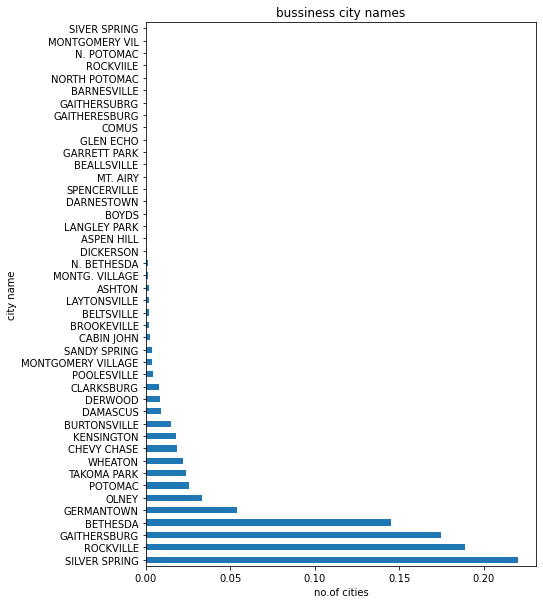

In [16]:
 # getting the bar plot for bussiness city names,to find in which location more business are having.
plot.figure(figsize=(7,10))
df1['business_city'].value_counts(normalize=True).plot.barh() 
plot.title("bussiness city names")
plot.xlabel("no.of cities")
plot.ylabel("city name")
plot.show()

### yes

# 2. more inspections occured in 2015

Text(0.5, 1.0, 'no. of food inspections occured in particular year')

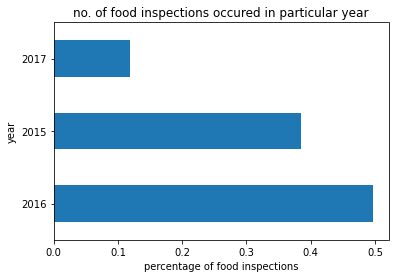

In [17]:
df1['date'] = p.to_datetime(df1['inspection_date'])
df1['year'] = df1['date'].dt.year              #extracting the year from given inspection date

df1['year'].value_counts(normalize=True).plot.barh()  # drawing barplot for years in which food inspection is occured
plot.xlabel("percentage of food inspections")
plot.ylabel("year")
plot.title("no. of food inspections occured in particular year")

### no,more inspections occured in 2016

# 3.most of the inspection results is fail

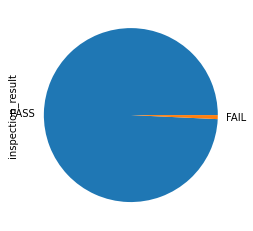

In [18]:
df1['inspection_result'].value_counts(normalize=True).plot.pie()    #drawing pieplot for inspection results
plot.show()

### no,most of the results are pass

# 4. routine food inspection is done mostly


Text(0, 0.5, 'total inspections')

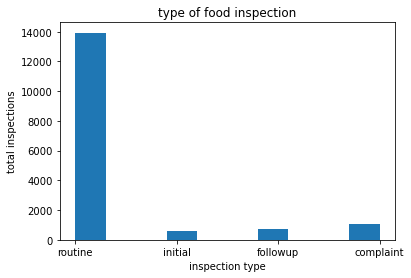

In [19]:
plot.hist(df1['inspection_type'])        #drawing histogram for type of food inspection occurred
plot.title("type of food inspection")
plot.xlabel("inspection type")
plot.ylabel("total inspections")

### yes

# 5.many acts of violence that occurred during food inspection are critical

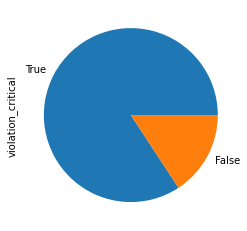

In [20]:
df1['violation_critical'].value_counts(normalize=True).plot.pie()  #drawing pieplot to find most of the violations are critical or not
plot.show()

### yes

# references:

https://towardsdatascience.com/exploratory-data-analysis-eda-python-87178e35b14

missing value:
https://www.makeuseof.com/fill-missing-data-with-pandas/

https://www.analyticsvidhya.com/blog/2021/10/handling-missing-value/